In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from sympy import lambdify
import sympy as sp

# 1. Point Python to your exact SRC directory
sys.path.append("/Users/adarshmac/simulations/bbh_run1/ANALYTICAL_CODES/SRC")

# 2. Import the engine AND EVERY metric available in your library
from Testsymbolicengine import (
    calculate_automated_fields, get_schwarzschild_spherical, get_schwarzschild_isotropic,
    get_reissner_nordstrom_spherical, get_reissner_nordstrom_isotropic,
    get_flrw_cartesian, get_bardeen_spherical, get_kerr_boyer_lindquist,
    get_kerr_quasi_isotropic_spherical, get_kerr_schild_cartesian
)

# 3. Load the geometry 
print("Loading Metric Geometry...")
metric_data = get_schwarzschild_spherical() # Load Kerr-Schild!

# 4. Execute the engine
print("Executing Tensor Calculus Engine...")
results = calculate_automated_fields(metric_data)

# 5. Extract ALL matrices (This is the critical update!)
E_hat = results['E_hat']
D_hat = results['D_hat']
B_hat = results['B_hat']
H_hat = results['H_hat']
rho_hat = results['rho_hat']
q_hat = results['q_hat']
s_hat = results['s_hat']
j_hat = results['j_hat']

# 6. UNIVERSAL SYMBOL EXTRACTION
print("Extracting variables...")
syms = results['symbols']

M = syms.get('M')
x = syms.get('x')
y = syms.get('y')
z = syms.get('z')

# Safely catch both standard 'r' and isotropic 'r_bar'
r = syms.get('r') if syms.get('r') is not None else syms.get('r_bar')
theta = syms.get('theta')
phi = syms.get('phi')

a = syms.get('a')    
Q = syms.get('Q')    
Qm = syms.get('Qm')  

print("Ready for plotting!")

Loading Metric Geometry...
Executing Tensor Calculus Engine...
Extracting variables...
Ready for plotting!


In [7]:
def plot_electric_field_cartesian(E_hat, slice_axis, x_sym, y_sym, z_sym, param_dict, horizon_radius):
    print(f"Rigorous Analysis: Gravito-Electric Field (E) on the {slice_axis}=0 plane...")
    
    full_subs = param_dict.copy()
    
    # 1. Dynamically configure the slice plane and extract the correct 3 vector components
    if slice_axis == 'Y':
        full_subs[y_sym] = 0.0
        h_sym, v_sym = x_sym, z_sym
        h_idx, v_idx, out_idx = 1, 3, 2  # In-plane: x, z. Out-of-plane: y
        h_label, v_label = "X (M)", "Z (M)"
        out_title = r"$E_{\hat{y}}$ (Out-of-Plane)"
    elif slice_axis == 'X':
        full_subs[x_sym] = 0.0
        h_sym, v_sym = y_sym, z_sym
        h_idx, v_idx, out_idx = 2, 3, 1  # In-plane: y, z. Out-of-plane: x
        h_label, v_label = "Y (M)", "Z (M)"
        out_title = r"$E_{\hat{x}}$ (Out-of-Plane)"
    elif slice_axis == 'Z':
        full_subs[z_sym] = 0.0
        h_sym, v_sym = x_sym, y_sym
        h_idx, v_idx, out_idx = 1, 2, 3  # In-plane: x, y. Out-of-plane: z
        h_label, v_label = "X (M)", "Y (M)"
        out_title = r"$E_{\hat{z}}$ (Out-of-Plane)"
    else:
        raise ValueError("slice_axis must be 'X', 'Y', or 'Z'")

    # 2. Extract and compile
    E_h_expr = E_hat[0, h_idx].subs(full_subs, simultaneous=True).doit()
    E_v_expr = E_hat[0, v_idx].subs(full_subs, simultaneous=True).doit()
    E_out_expr = E_hat[0, out_idx].subs(full_subs, simultaneous=True).doit()

    print("Compiling AST to C-code (CSE Activated)...")
    E_h_func = lambdify((h_sym, v_sym), E_h_expr, "numpy", cse=True)
    E_v_func = lambdify((h_sym, v_sym), E_v_expr, "numpy", cse=True)
    E_out_func = lambdify((h_sym, v_sym), E_out_expr, "numpy", cse=True)

    # 3. Evaluate Grid
    grid_lim = 8.0
    res = 300
    h_vals = np.linspace(-grid_lim, grid_lim, res)
    v_vals = np.linspace(-grid_lim, grid_lim, res)
    H_grid, V_grid = np.meshgrid(h_vals, v_vals)
    R = np.sqrt(H_grid**2 + V_grid**2)
    
    hr = horizon_radius if horizon_radius is not None else 0.0
    mask = R > (1.02 * hr) if hr > 0 else np.ones_like(R, dtype=bool)
    
    H_safe = np.where(mask, H_grid, 1.02 * hr)
    V_safe = np.where(mask, V_grid, 0.0)

    def safe_eval(func, in1, in2):
        res = np.asarray(func(in1, in2))
        if res.ndim == 0: return np.full_like(in1, res, dtype=float)
        return res

    E_h_num = np.zeros_like(R)
    E_v_num = np.zeros_like(R)
    E_out_num = np.zeros_like(R)

    E_h_num[mask] = safe_eval(E_h_func, H_safe[mask], V_safe[mask])
    E_v_num[mask] = safe_eval(E_v_func, H_safe[mask], V_safe[mask])
    E_out_num[mask] = safe_eval(E_out_func, H_safe[mask], V_safe[mask])

    E_h_num[~mask], E_v_num[~mask], E_out_num[~mask] = np.nan, np.nan, np.nan

    # 4. Render Deep-Dive Plot
    print("Rendering Electric Field Slice...")
    fig, ax = plt.subplots(figsize=(10, 8))
    
    out_max = np.nanmax(np.abs(E_out_num))
    if np.isnan(out_max) or out_max == 0: out_max = 1.0
    
    cmap = ax.pcolormesh(H_grid, V_grid, E_out_num, shading='auto', cmap='RdBu_r', vmin=-out_max, vmax=out_max)
    fig.colorbar(cmap, ax=ax, label=out_title)
    
    if np.any(E_h_num[mask] != 0) or np.any(E_v_num[mask] != 0):
        ax.streamplot(h_vals, v_vals, E_h_num, E_v_num, color='black', density=1.5, linewidth=0.8)
        
    if hr > 0: ax.add_patch(plt.Circle((0, 0), hr, color='black', zorder=10))
    ax.set_aspect('equal')
    ax.set_title(rf"Gravito-Electric Field ($\vec{{E}}$) on {slice_axis}=0 Slice", fontsize=16, fontweight='bold')
    ax.set_xlabel(h_label, fontsize=12)
    ax.set_ylabel(v_label, fontsize=12)

    plt.tight_layout()
    plt.show()

def plot_electric_field_spherical(E_hat, r_sym, theta_sym, param_dict, horizon_radius):
    print("Rigorous Analysis: Gravito-Electric Field (E) on the r-theta plane...")
    
    E_r_expr = E_hat[0, 1].subs(param_dict, simultaneous=True).doit()
    E_t_expr = E_hat[0, 2].subs(param_dict, simultaneous=True).doit()
    E_p_expr = E_hat[0, 3].subs(param_dict, simultaneous=True).doit() # Out-of-plane (phi)
    
    print("Compiling AST to C-code (CSE Activated)...")
    E_r_func = lambdify((r_sym, theta_sym), E_r_expr, "numpy", cse=True)
    E_t_func = lambdify((r_sym, theta_sym), E_t_expr, "numpy", cse=True)
    E_p_func = lambdify((r_sym, theta_sym), E_p_expr, "numpy", cse=True)
    
    grid_lim = 8.0
    res = 300
    x_vals = np.linspace(-grid_lim, grid_lim, res)
    z_vals = np.linspace(-grid_lim, grid_lim, res)
    X, Z = np.meshgrid(x_vals, z_vals)
    R = np.sqrt(X**2 + Z**2)
    R = np.where(R < 1e-5, 1e-5, R) 
    Theta = np.arccos(Z / R)
    
    hr = horizon_radius if horizon_radius is not None else 0.0
    mask = R > (1.02 * hr) if hr > 0 else np.ones_like(R, dtype=bool)
    R_safe = np.where(mask, R, 1.02 * hr)
    Theta_safe = np.where(mask, Theta, np.pi/2)

    def safe_eval(func, R_in, T_in):
        val = np.asarray(func(R_in, T_in))
        if val.ndim == 0: return np.full_like(R_in, val, dtype=float)
        return val

    E_r_num = np.zeros_like(R)
    E_t_num = np.zeros_like(R)
    E_p_num = np.zeros_like(R)
    
    E_r_num[mask] = safe_eval(E_r_func, R_safe[mask], Theta_safe[mask])
    E_t_num[mask] = safe_eval(E_t_func, R_safe[mask], Theta_safe[mask])
    E_p_num[mask] = safe_eval(E_p_func, R_safe[mask], Theta_safe[mask])
    
    sign_x = np.sign(X)
    sign_x[sign_x == 0] = 1.0 
    
    # Correct Spherical to Cartesian projection for the streamlines
    E_x_num = (E_r_num * np.sin(Theta) + E_t_num * np.cos(Theta)) * sign_x
    E_z_num = E_r_num * np.cos(Theta) - E_t_num * np.sin(Theta)
    
    E_x_num[~mask], E_z_num[~mask], E_p_num[~mask] = np.nan, np.nan, np.nan

    print("Rendering Electric Field Slice...")
    fig, ax = plt.subplots(figsize=(10, 8))
    
    p_max = np.nanmax(np.abs(E_p_num))
    if np.isnan(p_max) or p_max == 0: p_max = 1.0
    
    cmap = ax.pcolormesh(X, Z, E_p_num, shading='auto', cmap='RdBu_r', vmin=-p_max, vmax=p_max)
    fig.colorbar(cmap, ax=ax, label=r"$E_{\hat{\phi}}$ (Out-of-Plane)")
    
    if np.any(E_x_num[mask] != 0) or np.any(E_z_num[mask] != 0):
        ax.streamplot(x_vals, z_vals, E_x_num, E_z_num, color='black', density=1.5, linewidth=0.8)
        
    if hr > 0: ax.add_patch(plt.Circle((0, 0), hr, color='black', zorder=10))
    ax.set_aspect('equal')
    ax.set_title(rf"Gravito-Electric Field ($\vec{{E}}$) on Meridional Plane", fontsize=16, fontweight='bold')
    ax.set_xlabel("X (M)", fontsize=12)
    ax.set_ylabel("Z (M)", fontsize=12)

    plt.tight_layout()
    plt.show()

In [ ]:
# ==========================================
# MODULE 1: GRAVITO-ELECTRIC FIELD ANALYSIS
# ==========================================

SLICE_PLANE = 'Y' # Change to 'X', 'Y', or 'Z' to slice the Cartesian geometry

# 1. Define physics parameters
m_val = 1.0   
q_val = 0.8   
a_val = 0.8   
qm_val = 0.8  

param_dict = {}
if M is not None: param_dict[M] = m_val
if Q is not None: param_dict[Q] = q_val
if a is not None: param_dict[a] = a_val
if Qm is not None: param_dict[Qm] = qm_val
if syms.get('a_t') is not None:
    param_dict[syms['a_t']] = 1.0
    param_dict[sp.diff(syms['a_t'], syms['t'])] = 0.5 

# 2. Determine Horizon and Route to the specialized E-field plotter
if x is not None:
    if a is not None: horizon_r = m_val + np.sqrt(m_val**2 - a_val**2)
    elif Q is not None: horizon_r = 0.5 * np.sqrt(m_val**2 - q_val**2)
    elif M is None: horizon_r = None # Cosmological
    else: horizon_r = m_val / 2.0
        
    plot_electric_field_cartesian(E_hat, SLICE_PLANE, x, y, z, param_dict, horizon_radius=horizon_r)
    
else:
    if a is not None: horizon_r = m_val + np.sqrt(m_val**2 - a_val**2)
    elif Q is not None: horizon_r = m_val + np.sqrt(m_val**2 - q_val**2)
    elif Qm is not None: horizon_r = 1.62 * m_val
    else: horizon_r = 2.0 * m_val

    plot_electric_field_spherical(E_hat, r, theta, param_dict, horizon_radius=horizon_r)

In [2]:
def plot_magnetic_field_cartesian(B_hat, slice_axis, x_sym, y_sym, z_sym, param_dict, horizon_radius):
    print(f"Rigorous Analysis: Gravito-Magnetic Field (B) on the {slice_axis}=0 plane...")
    
    full_subs = param_dict.copy()
    
    # 1. Dynamically configure the slice plane and extract the correct 3 vector components
    if slice_axis == 'Y':
        full_subs[y_sym] = 0.0
        h_sym, v_sym = x_sym, z_sym
        h_idx, v_idx, out_idx = 1, 3, 2  # In-plane: x, z. Out-of-plane: y
        h_label, v_label = "X (M)", "Z (M)"
        out_title = r"$B_{\hat{y}}$ (Out-of-Plane)"
    elif slice_axis == 'X':
        full_subs[x_sym] = 0.0
        h_sym, v_sym = y_sym, z_sym
        h_idx, v_idx, out_idx = 2, 3, 1  # In-plane: y, z. Out-of-plane: x
        h_label, v_label = "Y (M)", "Z (M)"
        out_title = r"$B_{\hat{x}}$ (Out-of-Plane)"
    elif slice_axis == 'Z':
        full_subs[z_sym] = 0.0
        h_sym, v_sym = x_sym, y_sym
        h_idx, v_idx, out_idx = 1, 2, 3  # In-plane: x, y. Out-of-plane: z
        h_label, v_label = "X (M)", "Y (M)"
        out_title = r"$B_{\hat{z}}$ (Out-of-Plane)"
    else:
        raise ValueError("slice_axis must be 'X', 'Y', or 'Z'")

    # 2. Extract and compile
    B_h_expr = B_hat[0, h_idx].subs(full_subs, simultaneous=True).doit()
    B_v_expr = B_hat[0, v_idx].subs(full_subs, simultaneous=True).doit()
    B_out_expr = B_hat[0, out_idx].subs(full_subs, simultaneous=True).doit()

    print("Compiling AST to C-code (CSE Activated)...")
    B_h_func = lambdify((h_sym, v_sym), B_h_expr, "numpy", cse=True)
    B_v_func = lambdify((h_sym, v_sym), B_v_expr, "numpy", cse=True)
    B_out_func = lambdify((h_sym, v_sym), B_out_expr, "numpy", cse=True)

    # 3. Evaluate Grid
    grid_lim = 8.0
    res = 300
    h_vals = np.linspace(-grid_lim, grid_lim, res)
    v_vals = np.linspace(-grid_lim, grid_lim, res)
    H_grid, V_grid = np.meshgrid(h_vals, v_vals)
    R = np.sqrt(H_grid**2 + V_grid**2)
    
    hr = horizon_radius if horizon_radius is not None else 0.0
    mask = R > (1.02 * hr) if hr > 0 else np.ones_like(R, dtype=bool)
    
    H_safe = np.where(mask, H_grid, 1.02 * hr)
    V_safe = np.where(mask, V_grid, 0.0)

    def safe_eval(func, in1, in2):
        res = np.asarray(func(in1, in2))
        if res.ndim == 0: return np.full_like(in1, res, dtype=float)
        return res

    B_h_num = np.zeros_like(R)
    B_v_num = np.zeros_like(R)
    B_out_num = np.zeros_like(R)

    B_h_num[mask] = safe_eval(B_h_func, H_safe[mask], V_safe[mask])
    B_v_num[mask] = safe_eval(B_v_func, H_safe[mask], V_safe[mask])
    B_out_num[mask] = safe_eval(B_out_func, H_safe[mask], V_safe[mask])

    B_h_num[~mask], B_v_num[~mask], B_out_num[~mask] = np.nan, np.nan, np.nan

    # --- AUTO-DETECTION DIAGNOSTICS ---
    has_h = np.any(np.abs(B_h_num[mask]) > 1e-12)
    has_v = np.any(np.abs(B_v_num[mask]) > 1e-12)
    has_out = np.any(np.abs(B_out_num[mask]) > 1e-12)
    
    print("\n--- FIELD AUTO-DETECTION ---")
    print(f"Horizontal In-Plane Component: {'ACTIVE' if has_h else 'ZERO'}")
    print(f"Vertical In-Plane Component:   {'ACTIVE' if has_v else 'ZERO'}")
    print(f"Out-of-Plane Component:        {'ACTIVE' if has_out else 'ZERO'}")
    print("----------------------------\n")

    # 4. Render Deep-Dive Plot
    print("Rendering Magnetic Field Slice...")
    fig, ax = plt.subplots(figsize=(10, 8))
    
    out_max = np.nanmax(np.abs(B_out_num))
    if np.isnan(out_max) or out_max == 0: out_max = 1.0
    
    cmap = ax.pcolormesh(H_grid, V_grid, B_out_num, shading='auto', cmap='RdBu_r', vmin=-out_max, vmax=out_max)
    fig.colorbar(cmap, ax=ax, label=out_title)
    
    if has_h or has_v:
        ax.streamplot(h_vals, v_vals, B_h_num, B_v_num, color='black', density=1.5, linewidth=0.8)
        
    if hr > 0: ax.add_patch(plt.Circle((0, 0), hr, color='black', zorder=10))
    ax.set_aspect('equal')
    ax.set_title(rf"Gravito-Magnetic Field ($\vec{{B}}$) on {slice_axis}=0 Slice", fontsize=16, fontweight='bold')
    ax.set_xlabel(h_label, fontsize=12)
    ax.set_ylabel(v_label, fontsize=12)

    plt.tight_layout()
    plt.show()

def plot_magnetic_field_spherical(B_hat, r_sym, theta_sym, param_dict, horizon_radius):
    print("Rigorous Analysis: Gravito-Magnetic Field (B) on the r-theta plane...")
    
    B_r_expr = B_hat[0, 1].subs(param_dict, simultaneous=True).doit()
    B_t_expr = B_hat[0, 2].subs(param_dict, simultaneous=True).doit()
    B_p_expr = B_hat[0, 3].subs(param_dict, simultaneous=True).doit() # Out-of-plane (phi)
    
    print("Compiling AST to C-code (CSE Activated)...")
    B_r_func = lambdify((r_sym, theta_sym), B_r_expr, "numpy", cse=True)
    B_t_func = lambdify((r_sym, theta_sym), B_t_expr, "numpy", cse=True)
    B_p_func = lambdify((r_sym, theta_sym), B_p_expr, "numpy", cse=True)
    
    grid_lim = 8.0
    res = 300
    x_vals = np.linspace(-grid_lim, grid_lim, res)
    z_vals = np.linspace(-grid_lim, grid_lim, res)
    X, Z = np.meshgrid(x_vals, z_vals)
    R = np.sqrt(X**2 + Z**2)
    R = np.where(R < 1e-5, 1e-5, R) 
    Theta = np.arccos(Z / R)
    
    hr = horizon_radius if horizon_radius is not None else 0.0
    mask = R > (1.02 * hr) if hr > 0 else np.ones_like(R, dtype=bool)
    R_safe = np.where(mask, R, 1.02 * hr)
    Theta_safe = np.where(mask, Theta, np.pi/2)

    def safe_eval(func, R_in, T_in):
        val = np.asarray(func(R_in, T_in))
        if val.ndim == 0: return np.full_like(R_in, val, dtype=float)
        return val

    B_r_num = np.zeros_like(R)
    B_t_num = np.zeros_like(R)
    B_p_num = np.zeros_like(R)
    
    B_r_num[mask] = safe_eval(B_r_func, R_safe[mask], Theta_safe[mask])
    B_t_num[mask] = safe_eval(B_t_func, R_safe[mask], Theta_safe[mask])
    B_p_num[mask] = safe_eval(B_p_func, R_safe[mask], Theta_safe[mask])
    
    # --- AUTO-DETECTION DIAGNOSTICS ---
    has_r = np.any(np.abs(B_r_num[mask]) > 1e-12)
    has_t = np.any(np.abs(B_t_num[mask]) > 1e-12)
    has_p = np.any(np.abs(B_p_num[mask]) > 1e-12)
    
    print("\n--- FIELD AUTO-DETECTION ---")
    print(f"Radial Component (r):       {'ACTIVE' if has_r else 'ZERO'}")
    print(f"Polar Component (theta):    {'ACTIVE' if has_t else 'ZERO'}")
    print(f"Azimuthal Component (phi):  {'ACTIVE' if has_p else 'ZERO'}")
    print("----------------------------\n")

    sign_x = np.sign(X)
    sign_x[sign_x == 0] = 1.0 
    
    # Correct Spherical to Cartesian projection for the streamlines
    B_x_num = (B_r_num * np.sin(Theta) + B_t_num * np.cos(Theta)) * sign_x
    B_z_num = B_r_num * np.cos(Theta) - B_t_num * np.sin(Theta)
    
    B_x_num[~mask], B_z_num[~mask], B_p_num[~mask] = np.nan, np.nan, np.nan

    print("Rendering Magnetic Field Slice...")
    fig, ax = plt.subplots(figsize=(10, 8))
    
    p_max = np.nanmax(np.abs(B_p_num))
    if np.isnan(p_max) or p_max == 0: p_max = 1.0
    
    cmap = ax.pcolormesh(X, Z, B_p_num, shading='auto', cmap='RdBu_r', vmin=-p_max, vmax=p_max)
    fig.colorbar(cmap, ax=ax, label=r"$B_{\hat{\phi}}$ (Out-of-Plane)")
    
    if has_r or has_t:
        ax.streamplot(x_vals, z_vals, B_x_num, B_z_num, color='black', density=1.5, linewidth=0.8)
        
    if hr > 0: ax.add_patch(plt.Circle((0, 0), hr, color='black', zorder=10))
    ax.set_aspect('equal')
    ax.set_title(rf"Gravito-Magnetic Field ($\vec{{B}}$) on Meridional Plane", fontsize=16, fontweight='bold')
    ax.set_xlabel("X (M)", fontsize=12)
    ax.set_ylabel("Z (M)", fontsize=12)

    plt.tight_layout()
    plt.show()

Rigorous Analysis: Gravito-Magnetic Field (B) on the r-theta plane...
Compiling AST to C-code (CSE Activated)...

--- FIELD AUTO-DETECTION ---
Radial Component (r):       ZERO
Polar Component (theta):    ZERO
Azimuthal Component (phi):  ZERO
----------------------------

Rendering Magnetic Field Slice...


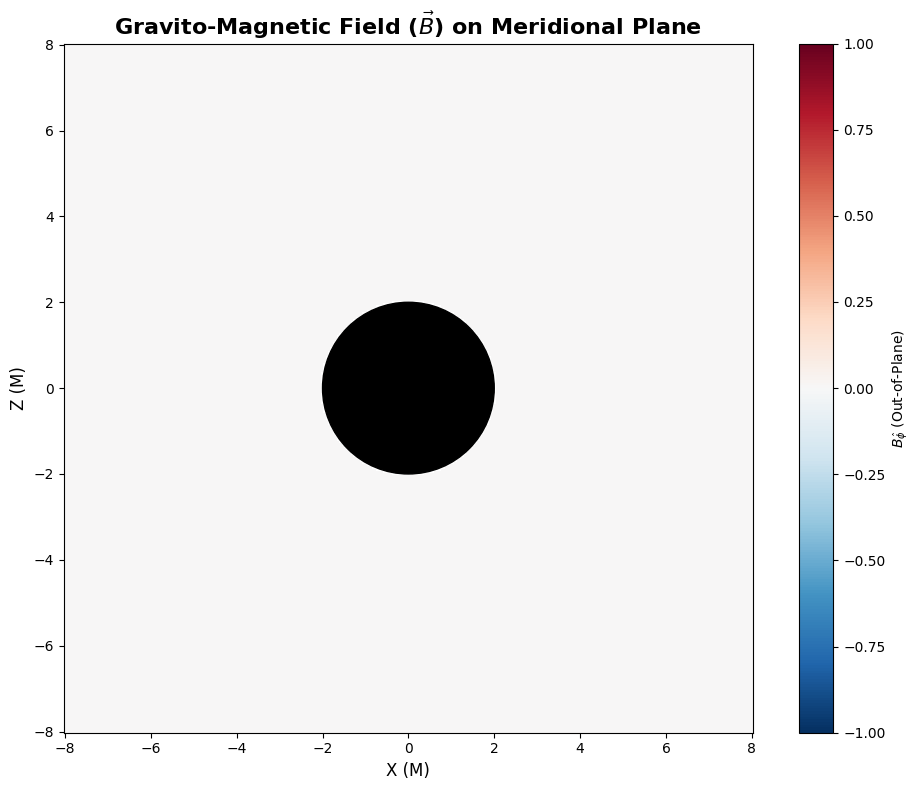

In [3]:
# ==========================================
# MODULE 2: GRAVITO-MAGNETIC FIELD ANALYSIS
# ==========================================

SLICE_PLANE = 'X' # Slice the Cartesian geometry (X, Y, or Z)

# 1. Define physics parameters
m_val = 1.0   
q_val = 0.8   
a_val = 0.8   # Kerr Spin parameter (Crucial for B-field generation!)
qm_val = 0.8  

param_dict = {}
if M is not None: param_dict[M] = m_val
if Q is not None: param_dict[Q] = q_val
if a is not None: param_dict[a] = a_val
if Qm is not None: param_dict[Qm] = qm_val
if syms.get('a_t') is not None:
    param_dict[syms['a_t']] = 1.0
    param_dict[sp.diff(syms['a_t'], syms['t'])] = 0.5 

# 2. Determine Horizon and Route to the specialized B-field plotter
if x is not None:
    if a is not None: horizon_r = m_val + np.sqrt(m_val**2 - a_val**2)
    elif Q is not None: horizon_r = 0.5 * np.sqrt(m_val**2 - q_val**2)
    elif M is None: horizon_r = None # Cosmological
    else: horizon_r = m_val / 2.0
        
    plot_magnetic_field_cartesian(B_hat, SLICE_PLANE, x, y, z, param_dict, horizon_radius=horizon_r)
    
else:
    if a is not None: horizon_r = m_val + np.sqrt(m_val**2 - a_val**2)
    elif Q is not None: horizon_r = m_val + np.sqrt(m_val**2 - q_val**2)
    elif Qm is not None: horizon_r = 1.62 * m_val
    else: horizon_r = 2.0 * m_val

    plot_magnetic_field_spherical(B_hat, r, theta, param_dict, horizon_radius=horizon_r)

In [27]:
def plot_D_field_cartesian(D_hat, slice_axis, x_sym, y_sym, z_sym, param_dict, horizon_radius):
    print(f"Rigorous Analysis: Macroscopic Electric Field (D) on the {slice_axis}=0 plane...")
    
    full_subs = param_dict.copy()
    
    if slice_axis == 'Y':
        full_subs[y_sym] = 0.0
        h_sym, v_sym = x_sym, z_sym
        h_idx, v_idx, out_idx = 1, 3, 2  
        h_label, v_label = "X (M)", "Z (M)"
        out_title = r"$D_{\hat{y}}$ (Out-of-Plane)"
    elif slice_axis == 'X':
        full_subs[x_sym] = 0.0
        h_sym, v_sym = y_sym, z_sym
        h_idx, v_idx, out_idx = 2, 3, 1  
        h_label, v_label = "Y (M)", "Z (M)"
        out_title = r"$D_{\hat{x}}$ (Out-of-Plane)"
    elif slice_axis == 'Z':
        full_subs[z_sym] = 0.0
        h_sym, v_sym = x_sym, y_sym
        h_idx, v_idx, out_idx = 1, 2, 3  
        h_label, v_label = "X (M)", "Y (M)"
        out_title = r"$D_{\hat{z}}$ (Out-of-Plane)"
    else:
        raise ValueError("slice_axis must be 'X', 'Y', or 'Z'")

    D_h_expr = D_hat[0, h_idx].subs(full_subs, simultaneous=True).doit()
    D_v_expr = D_hat[0, v_idx].subs(full_subs, simultaneous=True).doit()
    D_out_expr = D_hat[0, out_idx].subs(full_subs, simultaneous=True).doit()

    print("Compiling AST to C-code (CSE Activated)...")
    D_h_func = lambdify((h_sym, v_sym), D_h_expr, "numpy", cse=True)
    D_v_func = lambdify((h_sym, v_sym), D_v_expr, "numpy", cse=True)
    D_out_func = lambdify((h_sym, v_sym), D_out_expr, "numpy", cse=True)

    grid_lim = 8.0
    res = 300
    h_vals = np.linspace(-grid_lim, grid_lim, res)
    v_vals = np.linspace(-grid_lim, grid_lim, res)
    H_grid, V_grid = np.meshgrid(h_vals, v_vals)
    R = np.sqrt(H_grid**2 + V_grid**2)
    
    hr = horizon_radius if horizon_radius is not None else 0.0
    mask = R > (1.02 * hr) if hr > 0 else np.ones_like(R, dtype=bool)
    
    H_safe = np.where(mask, H_grid, 1.02 * hr)
    V_safe = np.where(mask, V_grid, 0.0)

    def safe_eval(func, in1, in2):
        res = np.asarray(func(in1, in2))
        if res.ndim == 0: return np.full_like(in1, res, dtype=float)
        return res

    D_h_num = np.zeros_like(R)
    D_v_num = np.zeros_like(R)
    D_out_num = np.zeros_like(R)

    D_h_num[mask] = safe_eval(D_h_func, H_safe[mask], V_safe[mask])
    D_v_num[mask] = safe_eval(D_v_func, H_safe[mask], V_safe[mask])
    D_out_num[mask] = safe_eval(D_out_func, H_safe[mask], V_safe[mask])

    D_h_num[~mask], D_v_num[~mask], D_out_num[~mask] = np.nan, np.nan, np.nan

    print("Rendering D Field Slice...")
    fig, ax = plt.subplots(figsize=(10, 8))
    
    out_max = np.nanmax(np.abs(D_out_num))
    if np.isnan(out_max) or out_max == 0: out_max = 1.0
    
    cmap = ax.pcolormesh(H_grid, V_grid, D_out_num, shading='auto', cmap='RdBu_r', vmin=-out_max, vmax=out_max)
    fig.colorbar(cmap, ax=ax, label=out_title)
    
    if np.any(D_h_num[mask] != 0) or np.any(D_v_num[mask] != 0):
        ax.streamplot(h_vals, v_vals, D_h_num, D_v_num, color='black', density=1.5, linewidth=0.8)
        
    if hr > 0: ax.add_patch(plt.Circle((0, 0), hr, color='black', zorder=10))
    ax.set_aspect('equal')
    ax.set_title(rf"Macroscopic Electric Field ($\vec{{D}}$) on {slice_axis}=0 Slice", fontsize=16, fontweight='bold')
    ax.set_xlabel(h_label, fontsize=12)
    ax.set_ylabel(v_label, fontsize=12)

    plt.tight_layout()
    plt.show()

def plot_D_field_spherical(D_hat, r_sym, theta_sym, param_dict, horizon_radius):
    print("Rigorous Analysis: Macroscopic Electric Field (D) on the r-theta plane...")
    
    D_r_expr = D_hat[0, 1].subs(param_dict, simultaneous=True).doit()
    D_t_expr = D_hat[0, 2].subs(param_dict, simultaneous=True).doit()
    D_p_expr = D_hat[0, 3].subs(param_dict, simultaneous=True).doit() 
    
    print("Compiling AST to C-code (CSE Activated)...")
    D_r_func = lambdify((r_sym, theta_sym), D_r_expr, "numpy", cse=True)
    D_t_func = lambdify((r_sym, theta_sym), D_t_expr, "numpy", cse=True)
    D_p_func = lambdify((r_sym, theta_sym), D_p_expr, "numpy", cse=True)
    
    grid_lim = 8.0
    res = 300
    x_vals = np.linspace(-grid_lim, grid_lim, res)
    z_vals = np.linspace(-grid_lim, grid_lim, res)
    X, Z = np.meshgrid(x_vals, z_vals)
    R = np.sqrt(X**2 + Z**2)
    R = np.where(R < 1e-5, 1e-5, R) 
    Theta = np.arccos(Z / R)
    
    hr = horizon_radius if horizon_radius is not None else 0.0
    mask = R > (1.02 * hr) if hr > 0 else np.ones_like(R, dtype=bool)
    R_safe = np.where(mask, R, 1.02 * hr)
    Theta_safe = np.where(mask, Theta, np.pi/2)

    def safe_eval(func, R_in, T_in):
        val = np.asarray(func(R_in, T_in))
        if val.ndim == 0: return np.full_like(R_in, val, dtype=float)
        return val

    D_r_num = np.zeros_like(R)
    D_t_num = np.zeros_like(R)
    D_p_num = np.zeros_like(R)
    
    D_r_num[mask] = safe_eval(D_r_func, R_safe[mask], Theta_safe[mask])
    D_t_num[mask] = safe_eval(D_t_func, R_safe[mask], Theta_safe[mask])
    D_p_num[mask] = safe_eval(D_p_func, R_safe[mask], Theta_safe[mask])
    
    sign_x = np.sign(X)
    sign_x[sign_x == 0] = 1.0 
    
    D_x_num = (D_r_num * np.sin(Theta) + D_t_num * np.cos(Theta)) * sign_x
    D_z_num = D_r_num * np.cos(Theta) - D_t_num * np.sin(Theta)
    
    D_x_num[~mask], D_z_num[~mask], D_p_num[~mask] = np.nan, np.nan, np.nan

    print("Rendering D Field Slice...")
    fig, ax = plt.subplots(figsize=(10, 8))
    
    p_max = np.nanmax(np.abs(D_p_num))
    if np.isnan(p_max) or p_max == 0: p_max = 1.0
    
    cmap = ax.pcolormesh(X, Z, D_p_num, shading='auto', cmap='RdBu_r', vmin=-p_max, vmax=p_max)
    fig.colorbar(cmap, ax=ax, label=r"$D_{\hat{\phi}}$ (Out-of-Plane)")
    
    if np.any(D_x_num[mask] != 0) or np.any(D_z_num[mask] != 0):
        ax.streamplot(x_vals, z_vals, D_x_num, D_z_num, color='black', density=1.5, linewidth=0.8)
        
    if hr > 0: ax.add_patch(plt.Circle((0, 0), hr, color='black', zorder=10))
    ax.set_aspect('equal')
    ax.set_title(rf"Macroscopic Electric Field ($\vec{{D}}$) on Meridional Plane", fontsize=16, fontweight='bold')
    ax.set_xlabel("X (M)", fontsize=12)
    ax.set_ylabel("Z (M)", fontsize=12)

    plt.tight_layout()
    plt.show()

In [ ]:
# ==========================================
# MODULE 3: MACROSCOPIC ELECTRIC FIELD (D) ANALYSIS
# ==========================================

SLICE_PLANE = 'Y' # Slice the Cartesian geometry (X, Y, or Z)

m_val = 1.0   
q_val = 0.8   
a_val = 0.8   
qm_val = 0.8  

param_dict = {}
if M is not None: param_dict[M] = m_val
if Q is not None: param_dict[Q] = q_val
if a is not None: param_dict[a] = a_val
if Qm is not None: param_dict[Qm] = qm_val
if syms.get('a_t') is not None:
    param_dict[syms['a_t']] = 1.0
    param_dict[sp.diff(syms['a_t'], syms['t'])] = 0.5 

if x is not None:
    if a is not None: horizon_r = m_val + np.sqrt(m_val**2 - a_val**2)
    elif Q is not None: horizon_r = 0.5 * np.sqrt(m_val**2 - q_val**2)
    elif M is None: horizon_r = None 
    else: horizon_r = m_val / 2.0
        
    plot_D_field_cartesian(D_hat, SLICE_PLANE, x, y, z, param_dict, horizon_radius=horizon_r)
    
else:
    if a is not None: horizon_r = m_val + np.sqrt(m_val**2 - a_val**2)
    elif Q is not None: horizon_r = m_val + np.sqrt(m_val**2 - q_val**2)
    elif Qm is not None: horizon_r = 1.62 * m_val
    else: horizon_r = 2.0 * m_val

    plot_D_field_spherical(D_hat, r, theta, param_dict, horizon_radius=horizon_r)